# Match galaxies in MaNGA sample with galaxies in Illustris TNG 100-1

#### imports

In [73]:
import illustris_python as il
import matplotlib.pyplot as plt
from astropy.table import Table
import h5py
import numpy as np
import tqdm
import matplotlib.cm as cm
import matplotlib as mpl



In [74]:
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['savefig.dpi'] = 300

#### load catalogs 

In [ ]:
# base_path = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/'
# fields = ['SubhaloFlag', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloVmax', 'SubhaloVmaxRad', 'SubhaloStellarPhotometricsMassInRad',
#          'SubhaloStellarPhotometricsRad', 'SubhaloHalfmassRadType', 'SubhaloSFR','SubhaloID']
# data = il.groupcat.loadSubhalos(base_path,99,fields=fields  

In [76]:
tng_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/IllustrisTNG100-1_sfr_subhalos.fits'
sfr = Table.read(tng_fn)
sfr[:5]

SubfindID,SubhaloFlag,SubhaloVmax,SubhaloMass,SubhaloMassInRadStar,SubhaloHalfmassRadStar,SubhaloStellarPhotometricsMassInRad,SubjaloStellarPhotometricsRad,SFR_10Myr,SFR_InRadStar_10Myr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,1.0,999.3851318359375,27477.935546875,163.83421325683594,47.388057708740234,139.7124786376953,139.7124786376953,3.476639822870808,0.12875327937099296
1,1.0,514.77587890625,3666.622802734375,25.731014251708984,17.012380599975586,21.47511863708496,21.47511863708496,0.8694901463325715,0.2527390986847066
2,1.0,461.6412658691406,773.4555053710938,28.852678298950195,14.983968734741211,27.32500457763672,27.32500457763672,17.46876927916618,5.6407731425460925
3,1.0,291.9365539550781,339.1330871582031,8.159035682678223,6.530275344848633,9.197443008422852,9.197443008422852,4.9834731637805705,2.7697557128170094
4,1.0,294.4329833984375,325.36669921875,6.276475429534912,8.990845680236816,5.133338928222656,5.133338928222656,1.4813834128018435,0.3892960413055264


In [88]:
master_table = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v9.fits')
test_sfr = master_table['SFR'][master_table['plateifu'] == '8997-9102']
test_mstar = master_table['sphd_M_star_h'][master_table['plateifu'] == '8997-9102']

In [119]:
np.where(master_table['plateifu'] == '8997-9102')

(array([9080]),)

In [116]:
# find closst match in sfr
dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/2713027700.py:2: RuntimeWarning: divide by zero encountered in log10
  dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2


In [117]:
sfr[np.argmin(dist2)]

SubfindID,SubhaloFlag,SubhaloVmax,SubhaloMass,SubhaloMassInRadStar,SubhaloHalfmassRadStar,SubhaloStellarPhotometricsMassInRad,SubjaloStellarPhotometricsRad,SFR_10Myr,SFR_InRadStar_10Myr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
501903,1.0,189.8396759033203,63.411964416503906,1.8252849578857422,3.346299171447754,1.840047836303711,1.840047836303711,2.6537609765706742,1.5716191968207742


In [120]:
test_sfr

0.192511375469816


In [121]:
test_mstar

10.2553222677357


In [122]:
np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10

10.261330674807109

In [123]:
np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)])

0.19634732493896345

In [135]:
np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]))-5

array([-4.43935236, -4.23805507, -4.17345374, ..., -4.5826254 ,
       -4.59311784, -4.39014648])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/1025423704.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')


Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

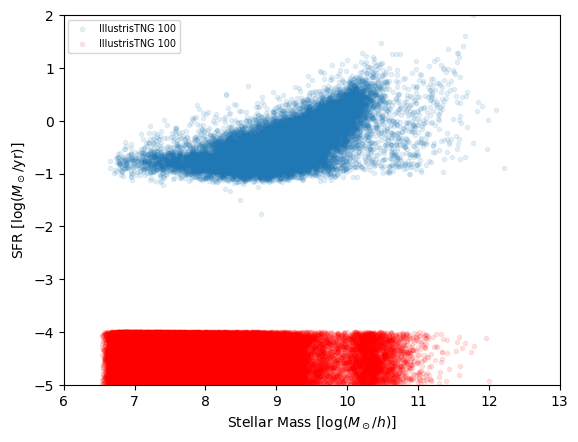

In [143]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')
# plt.scatter(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_err_h'], 
#             master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'], marker='x', alpha=0.1,
#            label='spiral and elliptical sample')
# plt.scatter(master_table['sphd_M_star_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10,
#             np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -5, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')


plt.legend(fontsize='x-small')
plt.xlim(6,13)
plt.ylim(-5,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

## attempt 1

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/2674408995.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)


Text(0, 0.5, 'Subhalo Mass $[M_\\odot/h]$')

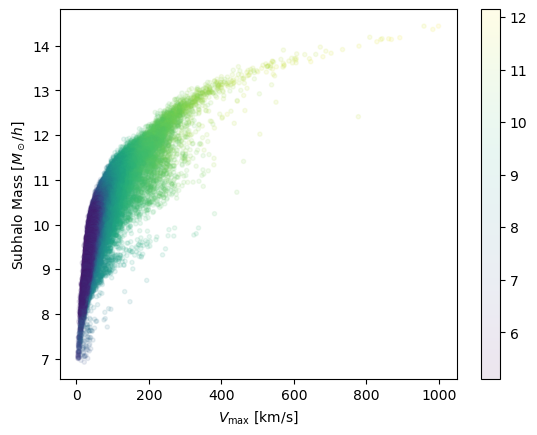

In [77]:
plt.scatter(data['SubhaloVmax'][data['SubhaloFlag']], np.log10(data['SubhaloMass'][data['SubhaloFlag']]) + 10, marker='.', alpha=0.1,
           c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)
plt.colorbar()
plt.xlabel(r'$V_{\rm max}$ [km/s]')
plt.ylabel(r'Subhalo Mass $[M_\odot/h]$')

In [25]:
r50_2 = data['SubhaloHalfmassRadType'][:,4]
r207 = data['SubhaloStellarPhotometricsRad']

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/287601697.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)


Text(0, 0.5, '20.7 mag/arcsec$^2$ K-band')

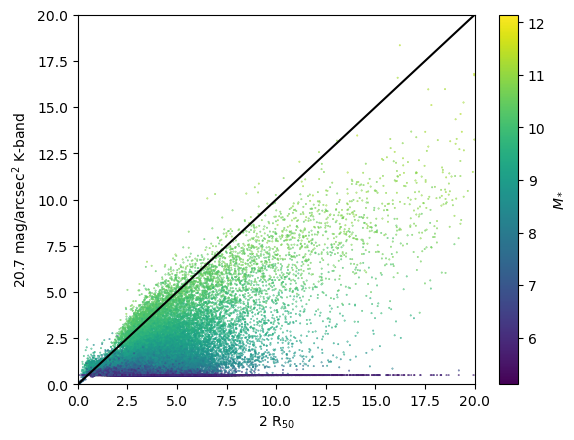

In [37]:
plt.scatter(r50_2[data['SubhaloFlag']]*2, r207[data['SubhaloFlag']], 
            c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)
plt.xlim(0,20)
plt.ylim(0,20)
plt.plot([0,20],[0,20], color='k')
plt.colorbar(label=r'$M_*$')
plt.xlabel(r'2 R$_{50}$')
plt.ylabel(r'20.7 mag/arcsec$^2$ K-band')

In [78]:
master_table = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v9.fits')
master_table[master_table['plateifu'] == '8997-9102']['SFR', 'sphd_M_star_h']

SFR,sphd_M_star_h
float64,float64
0.192511375469816,10.2553222677357


In [6]:
np.argmin((np.log10(data['Sub'][data['SubhaloFlag']]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 + \
(np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - master_table['SFR'][9080])**2)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/3573219432.py:1: RuntimeWarning: divide by zero encountered in log10
  np.argmin((np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 + \
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/3573219432.py:2: RuntimeWarning: divide by zero encountered in log10
  (np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - master_table['SFR'][9080])**2)


580093

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/2248263711.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/2248263711.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=0.1, label='IllustrisTNG 100')
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_86824/2248263711.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloSFR']==0]) + 10,


Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

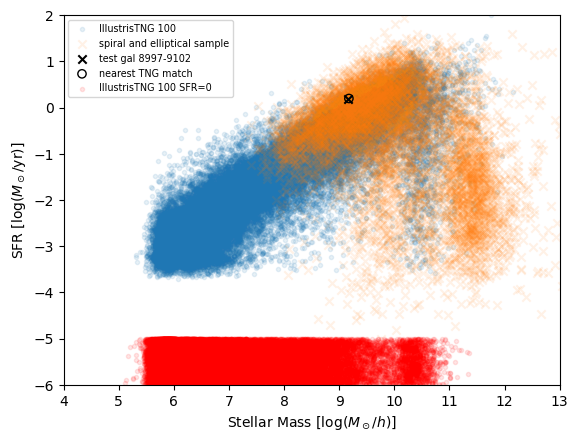

In [142]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=0.1, label='IllustrisTNG 100')
plt.scatter(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_err_h'], 
            master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'], marker='x', alpha=0.1,
           label='spiral and elliptical sample')
plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']][580093]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']][580093]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')


plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloSFR']==0]) + 10,
            np.random.rand(len(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloSFR']==0]))-6, marker='.', color='r', alpha=0.1, label='IllustrisTNG 100 SFR=0')


plt.legend(fontsize='x-small')
plt.xlim(4,13)
plt.ylim(-6,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3130469802.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3130469802.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10), marker='.', alpha=0.1, label='IllustrisTNG 100')
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3130469802.py:3: RuntimeWarning: invalid value encountered in subtract
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10), marker='.', alpha=0.1, label='IllustrisTNG 100')


Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

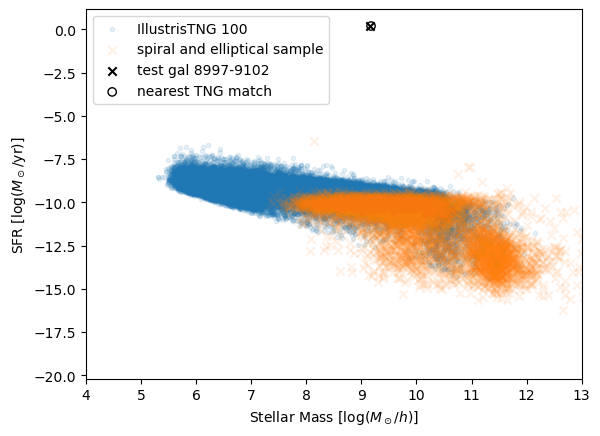

In [254]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10), marker='.', alpha=0.1, label='IllustrisTNG 100')
# plt.scatter(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_err_h'], 
#             master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'] - master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_h'], marker='x', alpha=0.1,
#            label='spiral and elliptical sample')
# plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']][580093]) + 10,
#             np.log10(data['SubhaloSFR'][data['SubhaloFlag']][580093]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.legend()
plt.xlim(4,13)
# plt.ylim(-6,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'sSFR $[\log(M_\odot/\rm yr)]$')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3056701178.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3056701178.py:1: RuntimeWarning: invalid value encountered in subtract
  plt.hist(np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10),


(array([  1.,   0.,   1.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   2.,
          1.,   2.,   6.,   5.,   7.,   6.,  11.,   4.,  10.,  19.,  15.,
         36.,  32.,  40.,  39.,  49.,  57.,  58.,  72.,  77.,  90.,  88.,
         93.,  86.,  90., 104.,  98., 106., 116., 115., 118., 105., 108.,
         95.,  95., 106.,  94.,  76.,  81.,  85.,  77.,  78.,  71.,  76.,
         70.,  90., 107., 128., 131., 175., 162., 211., 270., 320., 379.,
        489., 546., 550., 495., 416., 304., 191.,  77.,  38.,  22.,   3.,
          1.,   0.,   0.,   1.,   1.,   1.,   0.,   0.,   1.,   0.,   0.,
          0.,   2.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-17.        , -16.8989899 , -16.7979798 , -16.6969697 ,
        -16.5959596 , -16.49494949, -16.39393939, -16.29292929,
        -16.19191919, -16.09090909, -15.98989899, -15.88888889,
        -15.78787879, -15.68686869, -15.58585859, -15.48484848,
        -15.38383838, -15.28282828, -15.18181818, -15.08080808,
        -14.

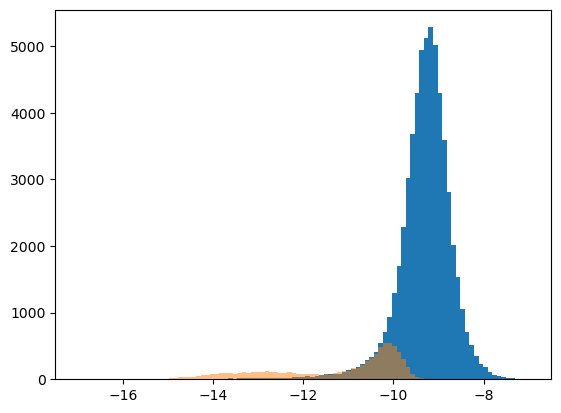

In [255]:
plt.hist(np.log10(data['SubhaloSFR'][data['SubhaloFlag']])- (np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10),
        bins= np.linspace(-17,-7,100))
plt.hist(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'] - master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_h'],
        bins= np.linspace(-17,-7,100), alpha=0.5)

### adding corresponding tng gals to master table

take the distance between each MaNGA gal and Illustris TNG gals in stellar mass-SFR plane. extract vmax, stellar mass, sfr and distance

In [91]:
#### create subsample of good tng gals
good_halo_vmax = data['SubhaloVmax'][data['SubhaloFlag']]
good_halo_mstar = np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10
good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3685398266.py:3: RuntimeWarning: divide by zero encountered in log10
  good_halo_mstar = np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/3685398266.py:4: RuntimeWarning: divide by zero encountered in log10
  good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])


In [90]:
master_table['TNG_Vmax'] = np.ones(len(master_table))*-999
master_table['TNG_Mstar'] = np.ones(len(master_table))*-999
master_table['TNG_SFR']= np.ones(len(master_table))*-999
master_table['TNG_distance']= np.ones(len(master_table))*-999

In [97]:
for i in tqdm.tqdm(range(len(master_table))):

    # check if gal in sample
    if master_table['elliptical_mask'][i] == 1 or master_table['spiral_mask'][i] == 1:

        manga_smass = master_table['sphd_M_star_h'][i]
        manga_sfr = master_table['SFR'][i]

        dists = (good_halo_mstar - manga_smass)**2 + (good_halo_sfr - manga_sfr)**2
        idx = np.argmin(dists)

        master_table['TNG_Vmax'][i] = good_halo_vmax[idx]
        master_table['TNG_Mstar'][i] = good_halo_mstar[idx]
        master_table['TNG_SFR'][i] = good_halo_sfr[idx]
        master_table['TNG_distance'][i] = np.sqrt(dists[idx])

  0%|                                         | 13/11273 [00:00<01:27, 129.09it/s]/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value
100%|██████████████████████████████████████| 11273/11273 [00:57<00:00, 197.35it/s]


In [104]:
sample = master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]

In [212]:
counts, bins = np.histogram(master_table['TNG_distance'], bins=np.linspace(0,5.2,50))
cmap = plt.get_cmap('rainbow')

In [208]:
cmap(5.2)

(1.0, 1.2246467991473532e-16, 6.123233995736766e-17, 1.0)

Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

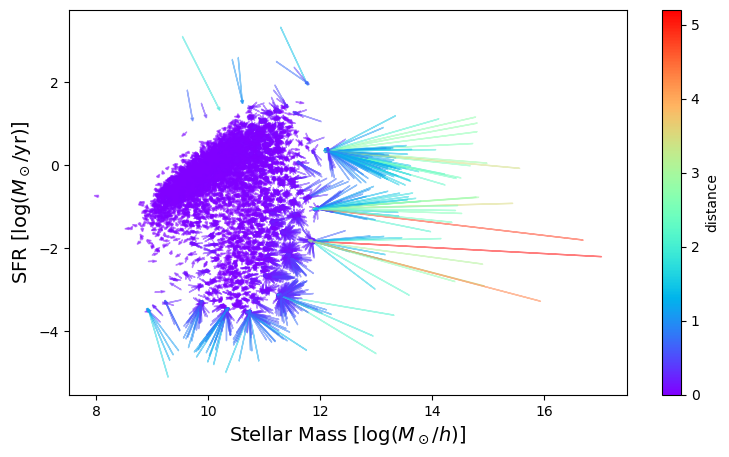

In [224]:
fig,ax = plt.subplots(1,1, figsize=(9,5))
for i in range(len(sample)):
    plt.arrow(sample['sphd_M_star_h'][i], sample['SFR'][i], 
              sample['TNG_Mstar'][i]-sample['sphd_M_star_h'][i], sample['TNG_SFR'][i]-sample['SFR'][i],
              alpha=0.5, color=cmap(sample['TNG_distance'][i]/5.2), head_width=0.05)

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 5.2), cmap='rainbow'),
             ax=ax, orientation='vertical', label='distance')

plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$', fontsize=14)

In [225]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]


In [227]:
master_table['TNG_MR90'] = np.ones(len(master_table))*-999
for i in range(len(master_table)):

    master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/1614506484.py:4: RuntimeWarning: invalid value encountered in log10
  master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)


(7.5, 13.0)

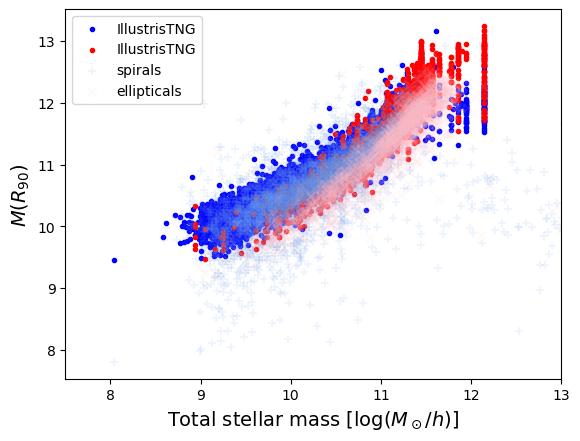

In [252]:
plt.scatter(master_table['TNG_Mstar'][master_table['spiral_mask']==1], 
            master_table['TNG_MR90'][master_table['spiral_mask']==1], alpha=1, marker='.', color='b', label='IllustrisTNG')
plt.scatter(master_table['TNG_Mstar'][master_table['elliptical_mask']==1], 
            master_table['TNG_MR90'][master_table['elliptical_mask']==1], alpha=1, marker='.', color='r', label='IllustrisTNG')

plt.scatter(master_table['sphd_M_star_h'][master_table['spiral_mask']==1], 
            master_table['M_R90'][master_table['spiral_mask']==1], 
            alpha=0.1, marker='+', color='cornflowerblue', label='spirals')
plt.scatter(master_table['sphd_M_star_h'][master_table['elliptical_mask']==1], 
            master_table['Mvir'][master_table['elliptical_mask']==1], 
            alpha=0.1, marker='x', color='pink', label='ellipticals')
plt.xlabel(r'Total stellar mass $[\log(M_\odot/h)]$', fontsize=14)
plt.ylabel(r'$M(R_{90})$', fontsize=14)
plt.legend()
plt.xlim(7.5,13)

### explore sfr table

In [9]:
sfr_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/star_formation_rates.hdf5'
sfr = h5py.File(sfr_fn, 'r')

In [17]:
for name in sfr['Snapshot_99']:
    print(name)

SFR_MsunPerYrs_in_InRad_1000Myrs
SFR_MsunPerYrs_in_InRad_100Myrs
SFR_MsunPerYrs_in_InRad_10Myrs
SFR_MsunPerYrs_in_InRad_200Myrs
SFR_MsunPerYrs_in_InRad_50Myrs
SFR_MsunPerYrs_in_all_1000Myrs
SFR_MsunPerYrs_in_all_100Myrs
SFR_MsunPerYrs_in_all_10Myrs
SFR_MsunPerYrs_in_all_200Myrs
SFR_MsunPerYrs_in_all_50Myrs
SFR_MsunPerYrs_in_r30pkpc_1000Myrs
SFR_MsunPerYrs_in_r30pkpc_100Myrs
SFR_MsunPerYrs_in_r30pkpc_10Myrs
SFR_MsunPerYrs_in_r30pkpc_200Myrs
SFR_MsunPerYrs_in_r30pkpc_50Myrs
SFR_MsunPerYrs_in_r5pkpc_1000Myrs
SFR_MsunPerYrs_in_r5pkpc_100Myrs
SFR_MsunPerYrs_in_r5pkpc_10Myrs
SFR_MsunPerYrs_in_r5pkpc_200Myrs
SFR_MsunPerYrs_in_r5pkpc_50Myrs
SubfindID


In [67]:
sfr['Snapshot_99']['SubfindID']

<HDF5 dataset "SubfindID": shape (116394,), type "<i4">

In [69]:
h = il.groupcat.loadSingle(base_path, 99, subhaloID=1)

In [70]:
h

{'SubhaloBHMass': 0.12551759,
 'SubhaloBHMdot': 0.0002301299,
 'SubhaloBfldDisk': 0.90148443,
 'SubhaloBfldHalo': 0.15268138,
 'SubhaloCM': array([  124.47653, 24606.768  , 16859.104  ], dtype=float32),
 'SubhaloFlag': True,
 'SubhaloGasMetalFractions': array([7.4376333e-01, 2.4799015e-01, 8.3335524e-04, 2.9013937e-04,
        4.0014386e-03, 1.3231143e-03, 3.8415098e-04, 3.9607051e-04,
        6.9444388e-04, 3.2380351e-04], dtype=float32),
 'SubhaloGasMetalFractionsHalfRad': array([7.3769665e-01, 2.5096405e-01, 1.1245606e-03, 4.1383362e-04,
        5.3651924e-03, 1.7890783e-03, 5.1718170e-04, 5.5794109e-04,
        1.0841856e-03, 4.8734748e-04], dtype=float32),
 'SubhaloGasMetalFractionsMaxRad': array([7.5244862e-01, 2.4395068e-01, 3.7734673e-04, 1.2004986e-04,
        1.8324659e-03, 5.9897872e-04, 1.7498418e-04, 1.6359941e-04,
        2.1959751e-04, 1.1368736e-04], dtype=float32),
 'SubhaloGasMetalFractionsSfr': array([7.4573088e-01, 2.4702457e-01, 7.0538727e-04, 2.3649352e-04,
      